<div style="border: 3px solid #0078B8; padding: 15px; border-radius: 12px; background-color: #00B6DA; text-align: center;">
  <h1 style="color: #000000;">Projet - Analyse du marché immobilier en France</h1>
</div>

### Objectif du projet 
L'investissement immobilier est l'un des placement préférés des Français et dans ce contexte ce projet a pour but d'identifier les communes en France qui présentent un potentiel intéressant pour un investissement immobilier.
Deux stratégies d'investissement sont étudiées : 

#### Investissement locatif 
L'objectif est d'identifier les communes permettant de générer un rendement locatif attractif. Avec comme critères :
- niveau des loyers
- prix d'achat du biens
- rendement locatif brut
- liquidité du marché immobilier
- tension locative

#### Investissement patrimonial 
Ici, la stratégie vise plutôt la valorisation du capital immobilier sur le long terme. Avec comme critères : 
- dynamique des prix immobiliers
- croissance démographique
- attractivité territoriale
- dynamisme du marché immobilier

Pour identifier les communes les plus attractives, j'ai combiné plusieurs sources de données publique : transactions immobilières (DVF), loyers estimés (Datagouv) et données démographiques (INSEE). L'analyse exploratoire et le nettoyage de ces données a été faite sur un premier notebook. Ici vous trouverez l'analyse du fichier final.

<div style="background-color: #0078B8; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">1 - Chargement et vérification des données</h2>
</div>

In [245]:
#Importation des librairies
import pandas as pd
import numpy as np
import plotly.express as px 
import seaborn as sns
import matplotlib.pyplot as plt

In [246]:
#Importation du dataset
df_immo = pd.read_csv("df_model_final.csv")

In [247]:
#Structure du DataFrame prêt pour l'analyse et la modélisation
print("Shape df_immo :", df_immo.shape)
print(df_immo.dtypes)
df_immo.head()

Shape df_immo : (57015, 14)
Code_INSEE                   object
annee                         int64
segment_bien                 object
prix_m2_median              float64
prix_m2_mean                float64
nb_ventes                     int64
surface_median              float64
valeur_median               float64
loyer_m2                    float64
nbobs_com                     int64
croissance_pop_2020_2023    float64
cagr_pop_2020_2023          float64
pop_missing                   int64
rendement_brut_pct          float64
dtype: object


,Code_INSEE,annee,segment_bien,prix_m2_median,prix_m2_mean,nb_ventes,surface_median,valeur_median,loyer_m2,nbobs_com,croissance_pop_2020_2023,cagr_pop_2020_2023,pop_missing,rendement_brut_pct
0,01001,2022,Maison,2812.500000,2800.050620,13,107.0,282000.0,8.638046,24,0.066991,0.021850,0,3.685566
1,01001,2023,Maison,2345.132743,3220.607801,15,90.0,270000.0,9.641002,29,0.066991,0.021850,0,4.933282
2,01004,2022,App_1_2,2822.332641,4656.777788,42,44.5,137500.0,13.076444,807,0.114377,0.036758,0,5.559845
3,01004,2022,App_3_plus,2279.411765,3140.841106,87,72.0,164000.0,9.377498,1014,0.114377,0.036758,0,4.936799
4,01004,2022,Maison,2616.666667,2716.105612,139,93.0,235250.0,8.825813,321,0.114377,0.036758,0,4.047507


<div style="background-color: #0078B8; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">2 - Analyse descriptive du marché immobilier</h2>
</div>

Cette première phase vise à comprendre la structure générale du marché immobilier français. Nous analysons notamment : 
- la distribution des prix au m² → Comprendre la dispersion des prix immobiliers à travers la France
- la distribution des loyers → identifier les zones locatives les plus chères; comparer les loyers entre segments
- la distribution des rendement locatifs → analyser la distribution nationale des rendements; les rendements par segment; les extrâmes du marché
- les différence entre types de biens → identifier les segments les plus favorables pour l'investissement locatif

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">2.1 - Distribution des prix au m² </h3>
</div>

In [248]:
#Filtrage des données pour l'analyse
sns.set(style="whitegrid")
df = df_immo.copy()

#Sélection année la plus récente (2024=)
df_2024 = df[df["annee"] == 2024].copy()

#Filtres qualité (nombre de vente et nombre d'observations par commune)
df_2024 = df_2024[
    (df_2024["nb_ventes"] >= 5) &
    (df_2024["nbobs_com"] >= 10)]

print("Nombre d'observations :", df_2024.shape)

Nombre d'observations : (16229, 14)


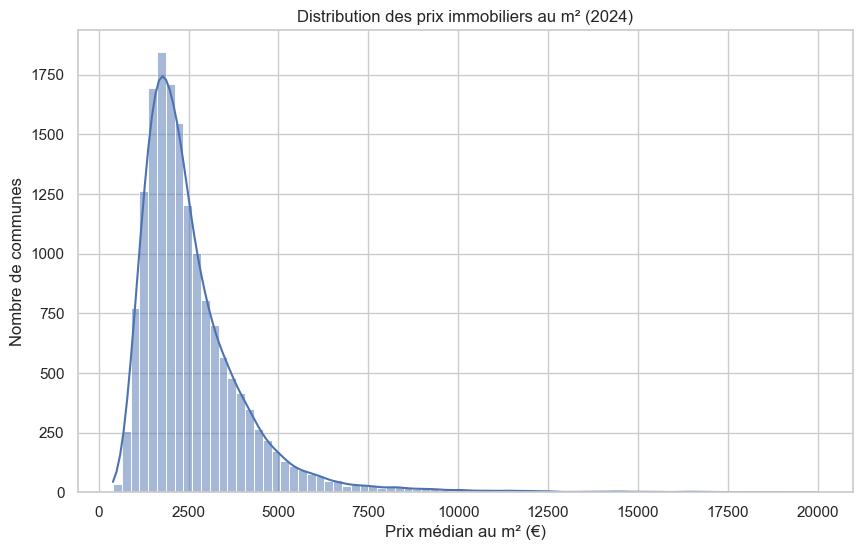

In [249]:
#Distribution des prix immobiliers au m² (2024)
plt.figure(figsize=(10,6))

sns.histplot(
    df_2024["prix_m2_median"],
    bins=80,
    kde=True)

plt.title("Distribution des prix immobiliers au m² (2024)")
plt.xlabel("Prix médian au m² (€)")
plt.ylabel("Nombre de communes")
plt.show()

- La majorité des communes se situe dans une fourchette comprise entre 1 500 € et 4 000 € par m². 
- La longue queue de distribution indique l'existence de marchés immobiliers plus chers pouvant dépasser 10 000 € / m².

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">2.2 - Distribution des loyers </h3>
</div>

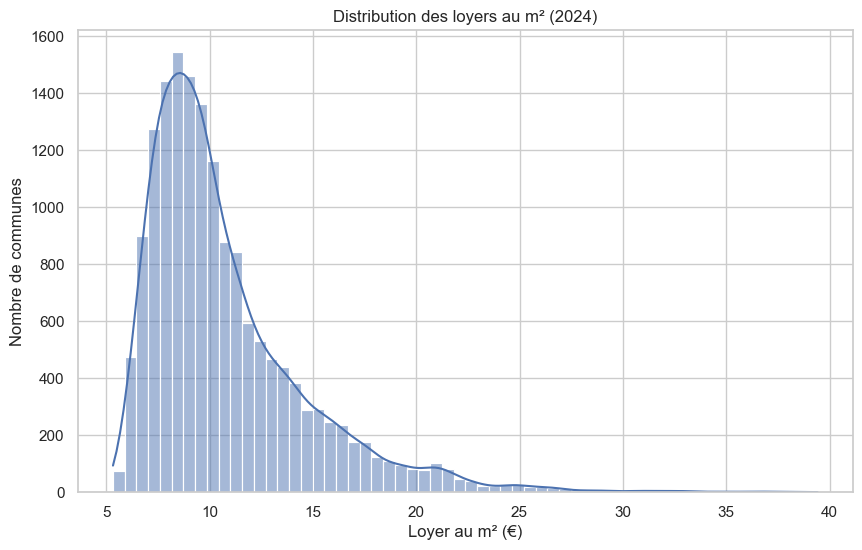

In [250]:
#Distribution des loyers au m² (2024)
plt.figure(figsize=(10,6))

sns.histplot(
    df_2024["loyer_m2"],
    bins=60,
    kde=True)

plt.title("Distribution des loyers au m² (2024)")
plt.xlabel("Loyer au m² (€)")
plt.ylabel("Nombre de communes")
plt.show()

- La majorité des loyers se situe entre 8 € et 15 € par m²
- Quelques marchés dépassent toutefois 20 € / m²
- Le marché locatif apparaît moins dispersé que le marché des prix immobiliers

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">2.3 - Distribution des rendement locatifs </h3>
</div>

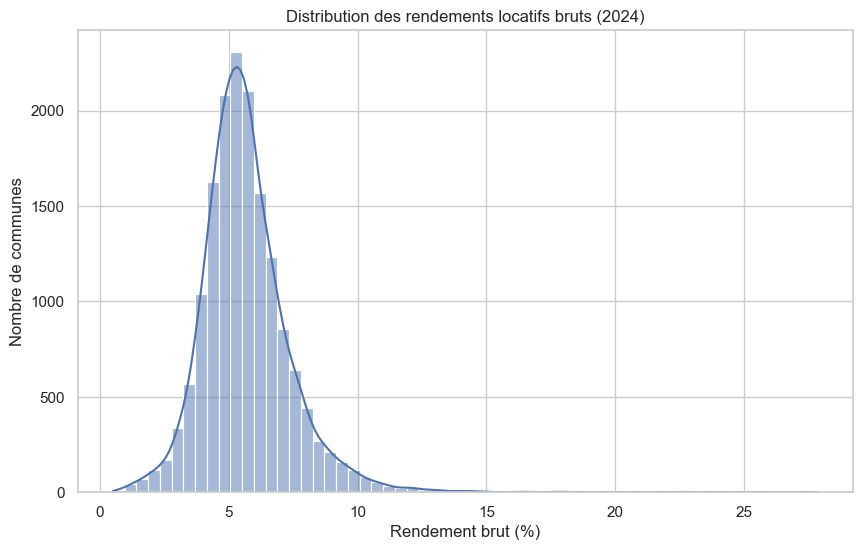

In [251]:
#Distribution des rendements locatifs bruts (2024)
plt.figure(figsize=(10,6))

sns.histplot(
    df_2024["rendement_brut_pct"],
    bins=60,
    kde=True)

plt.title("Distribution des rendements locatifs bruts (2024)")
plt.xlabel("Rendement brut (%)")
plt.ylabel("Nombre de communes")
plt.show()

- La majorité des communes se situe entre 4 % et 7 % de rendement brute.
- Quelques marchés affichent des rendements plus élevés pouvant dépasser 10 %.

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">2.4 - Comparaison entre segments immobiliers </h3>
</div>

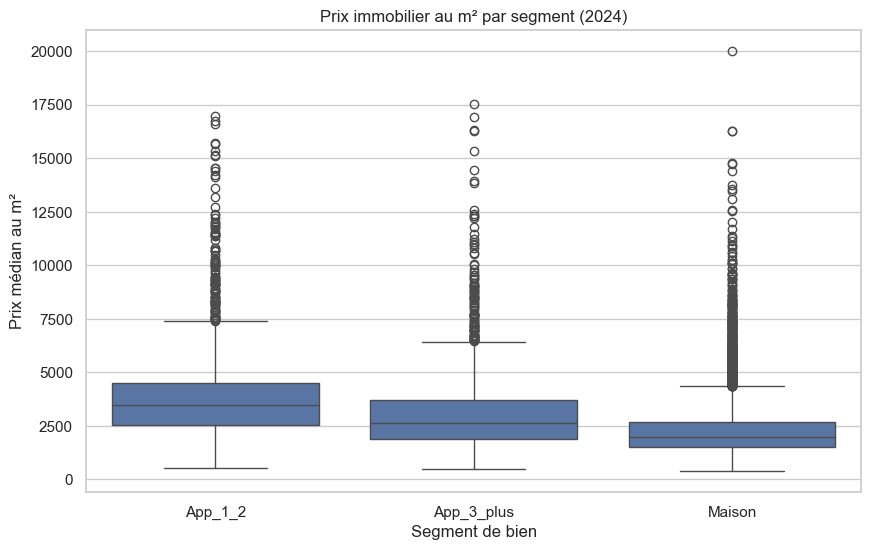

In [252]:
#Prix immobilier au m² par segment (2024)
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_2024,
    x="segment_bien",
    y="prix_m2_median")

plt.title("Prix immobilier au m² par segment (2024)")
plt.xlabel("Segment de bien")
plt.ylabel("Prix médian au m²")
plt.show()

- Appartement de petite taille présentent en moyenne les prix au m² les plus élevés.
- Les maisons affichent en moyenne des prix au m² plus faibles.

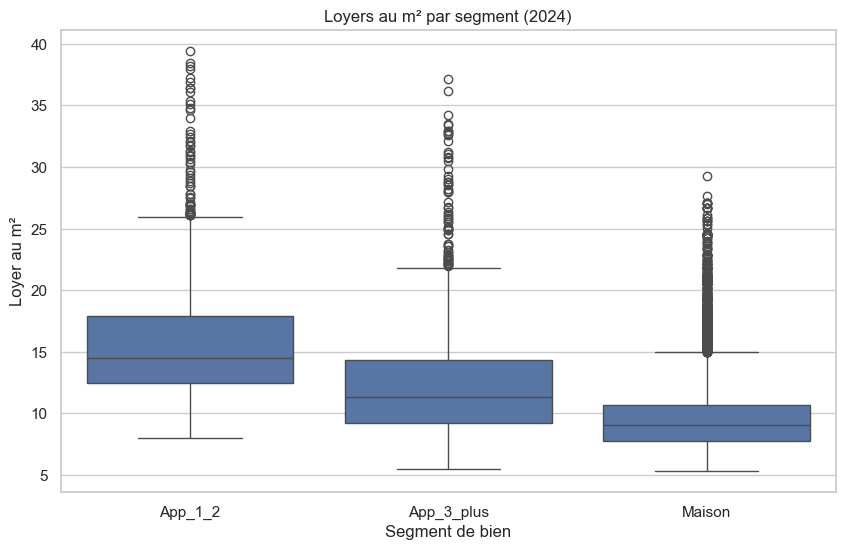

In [253]:
#Loyers au m² par segment (2024)
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_2024,
    x="segment_bien",
    y="loyer_m2")

plt.title("Loyers au m² par segment (2024)")
plt.xlabel("Segment de bien")
plt.ylabel("Loyer au m²")
plt.show()

Tendance similaire :
- petites surfaces présentent les loyers au m² les plus élevés
- les maisons affichent des loyers au m² plus faibles

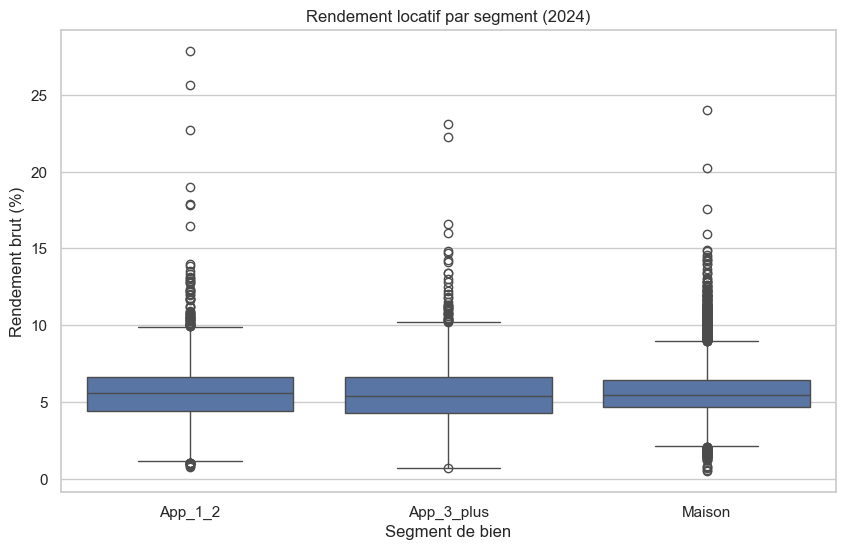

In [254]:
#Rendement locatif par segment (2024)
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_2024,
    x="segment_bien",
    y="rendement_brut_pct")

plt.title("Rendement locatif par segment (2024)")
plt.xlabel("Segment de bien")
plt.ylabel("Rendement brut (%)")
plt.show()

- Rendements locatifs apparaissent relativement similaires entre les segments, avec une médiane proche de 5 %.
- Maisons présentent une dipersion plus importante.
- Certaines communes affichent des rendements particulièrement élevés.

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">2.5 - Corrélation entre variables du marché immobilier</h3>
</div>

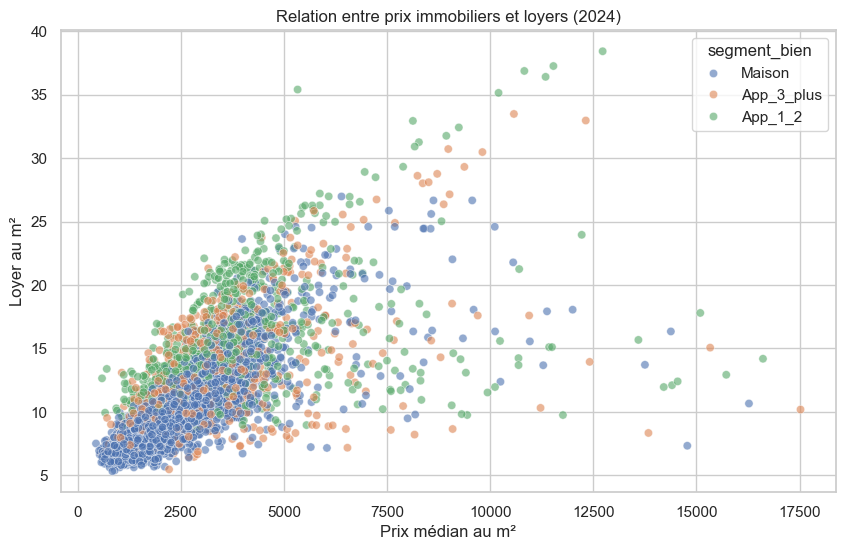

In [255]:
#Relation entre prix immobiliers et loyers (2024)
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_2024.sample(6000),
    x="prix_m2_median",
    y="loyer_m2",
    hue="segment_bien",
    alpha=0.6)

plt.title("Relation entre prix immobiliers et loyers (2024)")
plt.xlabel("Prix médian au m²")
plt.ylabel("Loyer au m²")
plt.show()

- Corrélation positive entre prix immobiliers et loyers.
- Certaines zones présentent des prix élevés mais des loyers relativement plus modérés.

Cette situation conduit à une compression des rendement locatifs dans les marchés les plus chers. les marchés immobiliers très chers ne sont pas nécessairement les plus intéressants pour un investissement locatif.

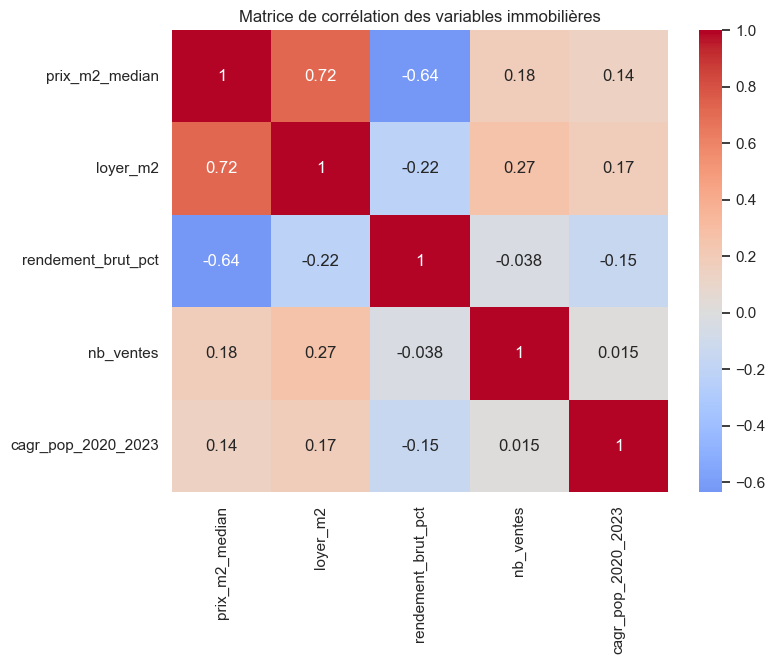

In [256]:
#Matrice de corrélation des variables immobilières (2024)
corr_vars = ["prix_m2_median","loyer_m2","rendement_brut_pct","nb_ventes","cagr_pop_2020_2023"]
corr = df_2024[corr_vars].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0)

plt.title("Matrice de corrélation des variables immobilières")
plt.show()

- Prix immobiliers et loyers 0.72 → les loyers augmentent globalement avec les prix immobliers.
- Prix immobiliers et rendement locatif - 0.64 → zones où les prix immobiliers sont élevés présentent généralment des rendements locatifs plus faibles.
- Loyers et rendement - 0.22 → les loyers élevés ne garantissent pas nécessairement un bon rendement si les prix immobiliers sont également très élevés.

#### Conclusion de l'analyse descriptive

L'analyse descriptive met en évidence plusieurs caractéristiques du marché immobilier français :

1. forte dispersion des prix immobiliers
2. marché locatif plus homogène que le marché des prix
3. rendement locatif médian autour de 5 %
4. relation positive entre prix et loyers
5. rendements généralement plus faibles dans les marchés immobiliers les plus chers

Ces résultats suggèrent que les meilleures opportunités d'investissement locatif pourraient se situer dans des marchés intermédiaires, où les prix restent modérés mais les loyers relativement élevés.

<div style="background-color: #0078B8; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">3 - Analyse géographique du marché immobilier</h2>
</div>

Le marché immobilier français est très hétérogène géographiquement, nous cherchons donc à identifier : 
- les zones où les prix sont élevés → identifier les marchés immobiliers les plus cher et les zones plus accessible
- les zones où les loyers sont élevés → identifier les zones à fort potentiel locatif
- les zones offrant les meilleurs rendements locatifs → identifier les zones offrant un bon compromis prix / loyers

Afin d'analyser la dimension territoriale, nous extrayons le code département à partir du code INSEE de la commune.

In [257]:
#Analyse géographique - Rendement locatif par département (2024)
df_geo = df_2024.copy()
df_geo["departement"] = df_geo["Code_INSEE"].str[:2]

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">3.1 - Prix immobiliers par territoire </h3>
</div>

In [258]:
#Calcul du prix médian au m² par département
prix_dept = (
    df_geo
    .groupby("departement")["prix_m2_median"]
    .median()
    .reset_index()
    .sort_values("prix_m2_median", ascending=False))

prix_dept.head(10)

,departement,prix_m2_median
72,75,10508.009153
89,92,6267.857143
5,06,4831.494795
28,2A,4586.857362
71,74,4437.037037
91,94,4410.512255
12,13,4011.956522
80,83,3879.279993
90,93,3734.866926
75,78,3686.538462


C:\Users\Thomas G\AppData\Local\Temp\ipykernel_12912\3440990766.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


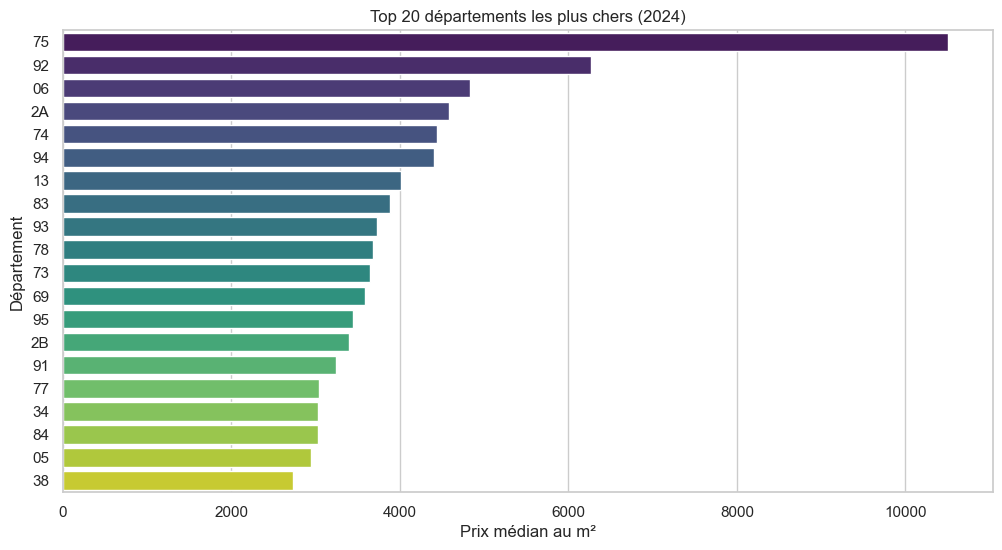

In [259]:
#Top 20 départements les plus chers (2024)
plt.figure(figsize=(12,6))

sns.barplot(
    data=prix_dept.head(20),
    x="prix_m2_median",
    y="departement",
    palette="viridis")

plt.title("Top 20 départements les plus chers (2024)")
plt.xlabel("Prix médian au m²")
plt.ylabel("Département")
plt.show()

Ces territoires correspondent généralment à : 
- des grandes métropoles 
- des zones littorales attractives
- des zones touristiques

La forte attractivité économique et démographique contribue à maintenir des prix immobiliers élevés.

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">3.2 - Loyer par territoire </h3>
</div>

In [260]:
#Calcul du loyer médian au m² par département
loyer_dept = (
    df_geo
    .groupby("departement")["loyer_m2"]
    .median()
    .reset_index()
    .sort_values("loyer_m2", ascending=False))

C:\Users\Thomas G\AppData\Local\Temp\ipykernel_12912\3140857424.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


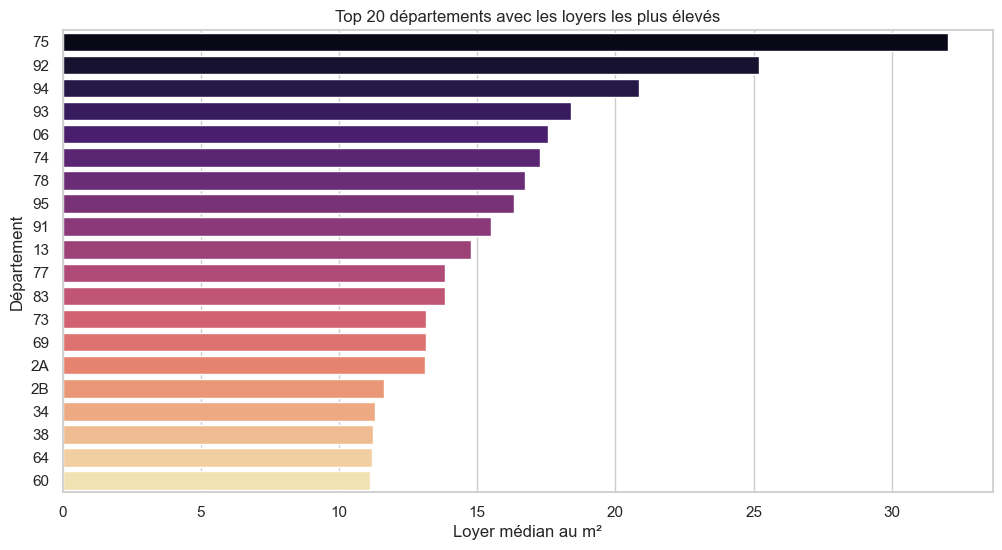

In [261]:
#Top 20 départements avec les loyers les plus élevés (2024)
plt.figure(figsize=(12,6))

sns.barplot(
    data=loyer_dept.head(20),
    x="loyer_m2",
    y="departement",
    palette="magma")

plt.title("Top 20 départements avec les loyers les plus élevés")
plt.xlabel("Loyer médian au m²")
plt.ylabel("Département")
plt.show()

Les loyers élevés sont principalement observés dans :
- les zones urbaines très denses
- les territoires où la tension locative est forte

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">3.3 - Rendements locatifs par territoire par territoire </h3>
</div>

In [262]:
#Calcul du rendement locatif médian par département
rendement_dept = (
    df_geo
    .groupby("departement")["rendement_brut_pct"]
    .median()
    .reset_index()
    .sort_values("rendement_brut_pct", ascending=False))

C:\Users\Thomas G\AppData\Local\Temp\ipykernel_12912\2718515583.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


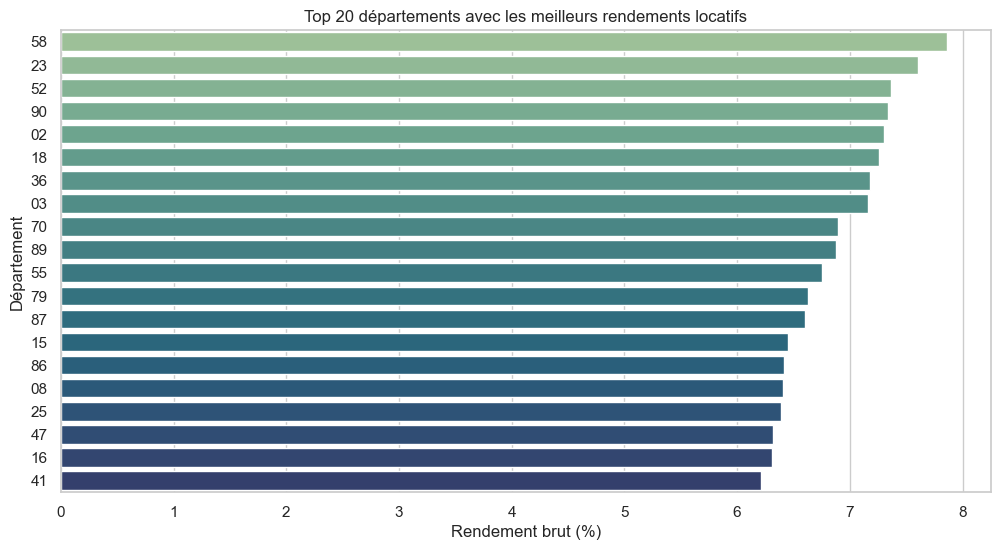

In [263]:
#Top 20 départements avec les meilleurs rendements locatifs (2024)
plt.figure(figsize=(12,6))

sns.barplot(
    data=rendement_dept.head(20),
    x="rendement_brut_pct",
    y="departement",
    palette="crest")

plt.title("Top 20 départements avec les meilleurs rendements locatifs")
plt.xlabel("Rendement brut (%)")
plt.ylabel("Département")
plt.show()

Ces territoires présentent des prix immobiliers relativement faibles mais surement avec une demande locative plus faible et un marché immobilier moins liquide.

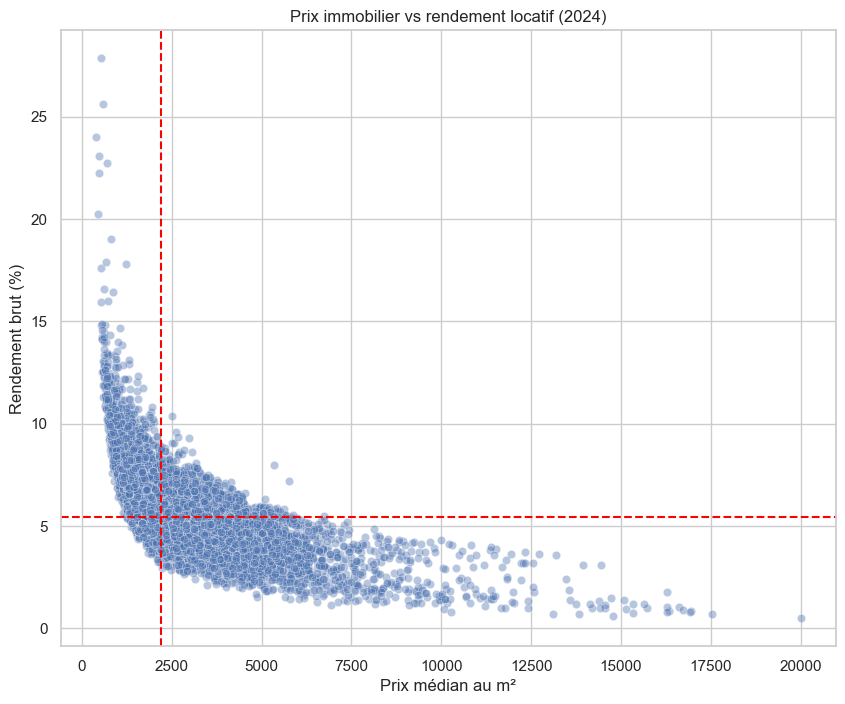

In [264]:
#Relation entre prix immobilier et rendement locatif (2024)
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df_geo,
    x="prix_m2_median",
    y="rendement_brut_pct",
    alpha=0.4)

plt.axhline(df_geo["rendement_brut_pct"].median(), color="red", linestyle="--")
plt.axvline(df_geo["prix_m2_median"].median(), color="red", linestyle="--")

plt.title("Prix immobilier vs rendement locatif (2024)")
plt.xlabel("Prix médian au m²")
plt.ylabel("Rendement brut (%)")
plt.show()

Ce graphique permet d'identifier plusieurs typesde marchés : 
- marchés patrimoniaux → prix élevés; rendement faibles
- marchés à fort rendement → prix modéré; rendements élevés

<div style="background-color: #0078B8; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">4 - Evolution du marché immobilier (2022-2024)</h2>
</div>

Nous analysons ici l'évolution récente du marché immobilier selon plusieurs indicateurs : 
- évolution des prix → analyse de variations du prix au m² entre 2022 et 2024
- évolution des loyers → analyse des variations des loyers pour identifier les zones où la pression locative augmente; les loyers stagnent
- évolution des rendements → anlyse la compression du rendement (prix augmentent plus vite que les loyers) ou l'expansion du rendement (loyers augmentent plus vite que les prix)

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">4.1 - Evolution des prix immobiliers </h3>
</div>

In [265]:
#Création de la variable "departement" à partir du code INSEE
df_immo["departement"] = df_immo["Code_INSEE"].str[:2]

In [266]:
#Calcul du prix médian au m² par département et par année
prix_dept_year = (
    df_immo
    .groupby(["annee","departement"])["prix_m2_median"]
    .median()
    .reset_index())

prix_dept_year.head()

,annee,departement,prix_m2_median
0,2022,01,2516.097561
1,2022,02,1463.499903
2,2022,03,1294.117647
3,2022,04,2432.907429
4,2022,05,2799.145981


Pour améliorer la lisibilité du graphique, nous analysons l'évolution des prix dans les 10 départements les plus chers en 2024.

In [267]:
#Identification des départements les plus chers en 2024
top_dept = (
    df_immo[df_immo["annee"]==2024]
    .groupby("departement")["prix_m2_median"]
    .median()
    .sort_values(ascending=False)
    .head(10)
    .index)

df_top = prix_dept_year[prix_dept_year["departement"].isin(top_dept)]

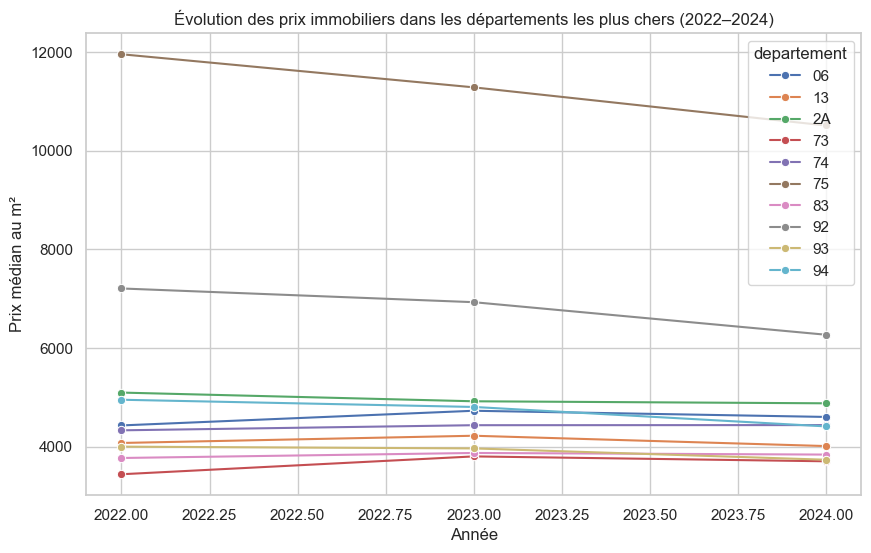

In [268]:
#Évolution des prix immobiliers dans les départements les plus chers (2022–2024)
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_top,
    x="annee",
    y="prix_m2_median",
    hue="departement",
    marker="o")

plt.title("Évolution des prix immobiliers dans les départements les plus chers (2022–2024)")
plt.xlabel("Année")
plt.ylabel("Prix médian au m²")
plt.show()

In [269]:
#Calcul de l'évolution en pourcentage des prix immobiliers entre 2022 et 2024 pour les départements les plus chers
prix_pivot = prix_dept_year.pivot(
    index="departement",
    columns="annee",
    values="prix_m2_median")

prix_pivot["evolution_pct"] = ((prix_pivot[2024] - prix_pivot[2022]) / prix_pivot[2022] * 100)

prix_pivot = prix_pivot.reset_index()

In [270]:
#Top 10 départements avec la plus forte croissance des prix immobiliers entre 2022 et 2024
top_growth = prix_pivot.sort_values("evolution_pct",ascending=False).head(10)
top_growth

annee,departement,2022,2023,2024,evolution_pct
43,43,1618.750000,1766.292135,1775.286408,9.670203
14,15,1421.022727,1388.888889,1553.181818,9.300280
11,12,1515.151515,1606.145833,1644.230769,8.519231
70,73,3440.795455,3802.380952,3703.491943,7.634760
4,05,2799.145981,2907.586164,2994.172932,6.967373
62,63,1848.983038,1895.190479,1973.569814,6.738124
10,11,1815.928270,1810.344828,1918.095238,5.626157
37,37,1923.076923,2110.169492,2021.276596,5.106383
21,23,1035.252334,1023.839326,1086.688137,4.968432
83,86,1366.187050,1425.649351,1431.587577,4.787084


C:\Users\Thomas G\AppData\Local\Temp\ipykernel_12912\2290516317.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


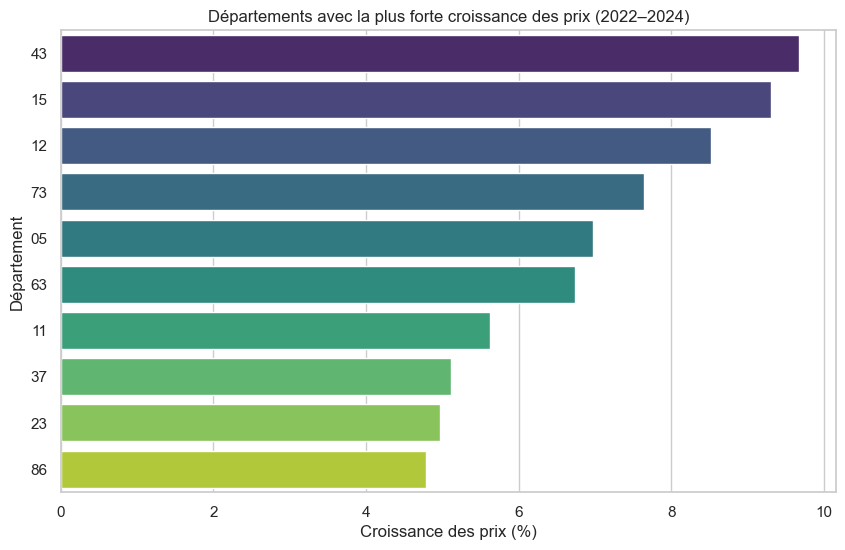

In [271]:
#Visualisation des départements avec la plus forte croissance des prix immobiliers (2022–2024)
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_growth,
    x="evolution_pct",
    y="departement",
    palette="viridis")

plt.title("Départements avec la plus forte croissance des prix (2022–2024)")
plt.xlabel("Croissance des prix (%)")
plt.ylabel("Département")
plt.show()

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">4.2 - Evolution des loyers </h3>
</div>

In [272]:
#Calcul du loyer médian au m² par département et par année
loyer_dept_year = (
    df_immo
    .groupby(["annee","departement"])["loyer_m2"]
    .median()
    .reset_index())

loyer_dept_year.head()

,annee,departement,loyer_m2
0,2022,01,9.380161
1,2022,02,7.475956
2,2022,03,6.544041
3,2022,04,8.892224
4,2022,05,9.190281


In [273]:
#Identification des départements avec les loyers les plus élevés en 2024
top_loyer_dept = (
    df_immo[df_immo["annee"]==2024]
    .groupby("departement")["loyer_m2"]
    .median()
    .sort_values(ascending=False)
    .head(10)
    .index)

df_loyer_top = loyer_dept_year[loyer_dept_year["departement"].isin(top_loyer_dept)]

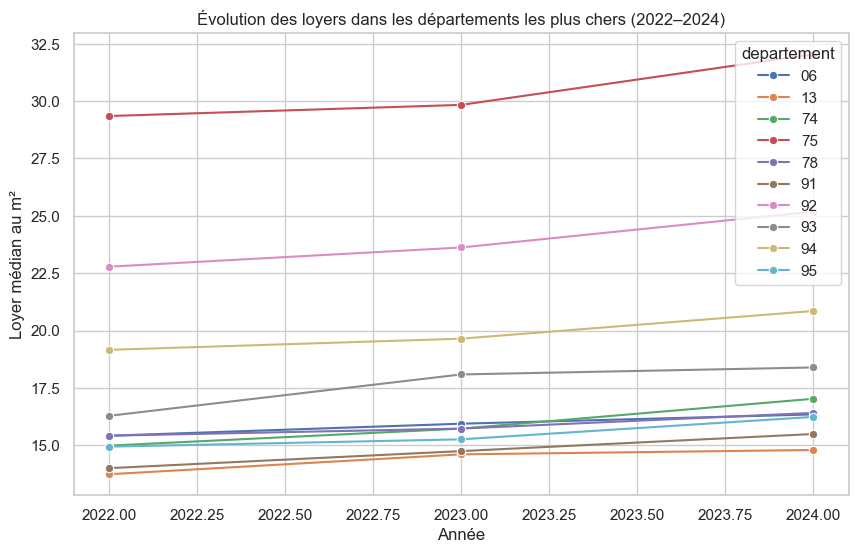

In [274]:
#Évolution des loyers dans les départements les plus chers (2022–2024)
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_loyer_top,
    x="annee",
    y="loyer_m2",
    hue="departement",
    marker="o")

plt.title("Évolution des loyers dans les départements les plus chers (2022–2024)")
plt.xlabel("Année")
plt.ylabel("Loyer médian au m²")
plt.show()

In [275]:
#Calcul de l'évolution en pourcentage des loyers entre 2022 et 2024 pour les départements les plus chers
loyer_pivot = loyer_dept_year.pivot(
    index="departement",
    columns="annee",
    values="loyer_m2")

loyer_pivot["evolution_pct"] = ((loyer_pivot[2024] - loyer_pivot[2022]) / loyer_pivot[2022] * 100)

loyer_pivot = loyer_pivot.reset_index()

In [276]:
#Top 10 départements avec la plus forte croissance des loyers entre 2022 et 2024
top_loyer_growth = loyer_pivot.sort_values("evolution_pct",ascending=False).head(10)
top_loyer_growth

annee,departement,2022,2023,2024,evolution_pct
70,73,11.166798,11.215058,13.226732,18.446955
39,39,7.818849,8.305658,9.257663,18.401864
87,90,9.117576,9.100670,10.648417,16.789994
63,64,9.409691,10.319071,10.935055,16.210573
42,42,7.971244,8.516827,9.213579,15.585219
56,56,8.779378,9.529647,10.091497,14.945469
15,16,6.824223,7.453371,7.799112,14.285714
2,03,6.544041,7.139624,7.471625,14.174487
35,35,8.338506,8.995799,9.510997,14.061158
83,86,6.649343,6.867975,7.565774,13.782282


C:\Users\Thomas G\AppData\Local\Temp\ipykernel_12912\1633684119.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


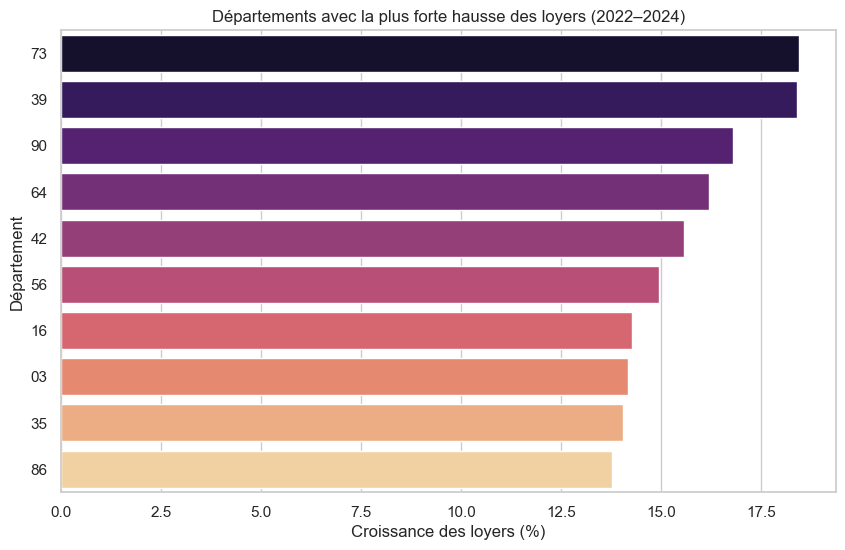

In [277]:
#Visualisation des départements avec la plus forte croissance des loyers (2022–2024)
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_loyer_growth,
    x="evolution_pct",
    y="departement",
    palette="magma")

plt.title("Départements avec la plus forte hausse des loyers (2022–2024)")
plt.xlabel("Croissance des loyers (%)")
plt.ylabel("Département")
plt.show()

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">4.3 - Compression et expansion des rendements </h3>
</div>

In [278]:
#Calcul du rendement locatif médian par département et par année
rendement_year = (
    df_immo
    .groupby("annee")["rendement_brut_pct"]
    .median()
    .reset_index())

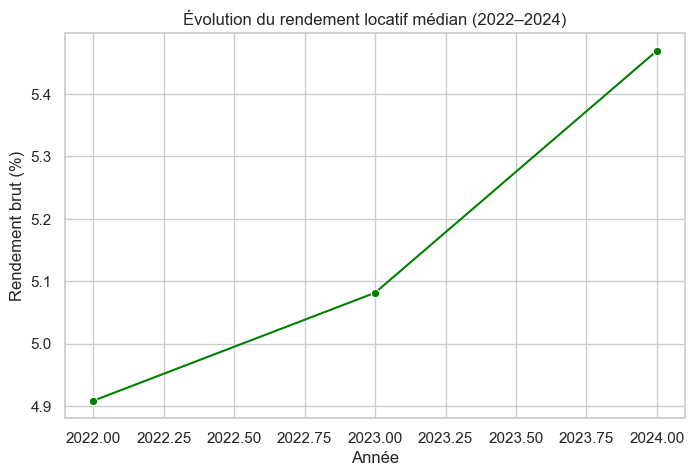

In [279]:
#Évolution du rendement locatif médian (2022–2024)
plt.figure(figsize=(8,5))

sns.lineplot(
    data=rendement_year,
    x="annee",
    y="rendement_brut_pct",
    marker="o",
    color="green")

plt.title("Évolution du rendement locatif médian (2022–2024)")
plt.xlabel("Année")
plt.ylabel("Rendement brut (%)")
plt.show()

In [280]:
#Calcul du rendement locatif médian par département et par année
rendement_dept_year = (
    df_immo
    .groupby(["annee","departement"])["rendement_brut_pct"]
    .median()
    .reset_index())

rendement_dept_year.head()

,annee,departement,rendement_brut_pct
0,2022,01,4.503268
1,2022,02,6.290288
2,2022,03,6.306904
3,2022,04,4.436900
4,2022,05,4.375637


In [281]:
#Identification des départements avec les meilleurs rendements locatifs en 2024
top_rendement_dept = (
    df_immo[df_immo["annee"]==2024]
    .groupby("departement")["rendement_brut_pct"]
    .median()
    .sort_values(ascending=False)
    .head(10)
    .index)

df_rendement_top = rendement_dept_year[rendement_dept_year["departement"].isin(top_rendement_dept)]

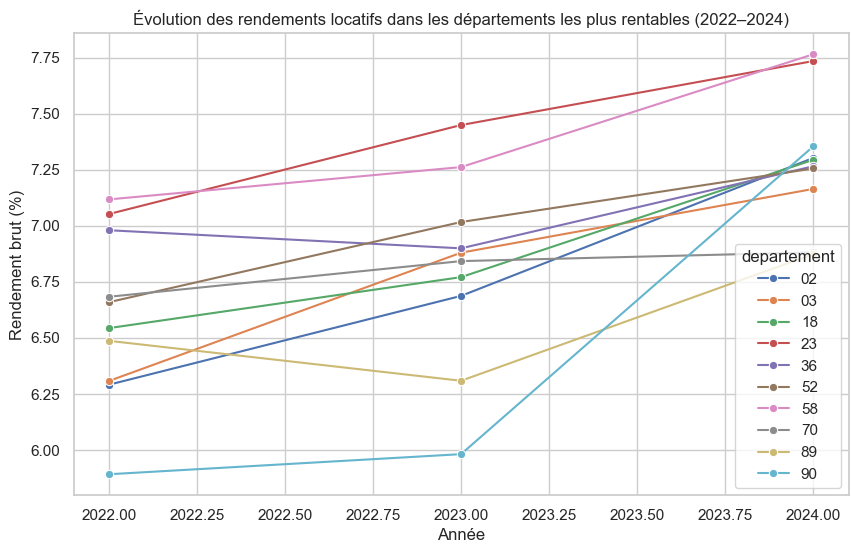

In [282]:
#Évolution des rendements locatifs dans les départements les plus rentables (2022–2024)
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_rendement_top,
    x="annee",
    y="rendement_brut_pct",
    hue="departement",
    marker="o")

plt.title("Évolution des rendements locatifs dans les départements les plus rentables (2022–2024)")
plt.xlabel("Année")
plt.ylabel("Rendement brut (%)")
plt.show()

In [283]:
#Calcul de l'évolution en pourcentage des rendements locatifs entre 2022 et 2024 pour les départements les plus rentables
rendement_pivot = rendement_dept_year.pivot(
    index="departement",
    columns="annee",
    values="rendement_brut_pct")

rendement_pivot["evolution_pct"] = ((rendement_pivot[2024] - rendement_pivot[2022]) / rendement_pivot[2022] * 100)
rendement_pivot = rendement_pivot.reset_index()

In [284]:
#Top 10 départements avec la plus forte croissance des rendements locatifs entre 2022 et 2024
top_rendement_growth = rendement_pivot.sort_values("evolution_pct",ascending=False).head(10)
top_rendement_growth

annee,departement,2022,2023,2024,evolution_pct
89,92,3.842798,4.200819,4.801705,24.953351
87,90,5.890958,5.980687,7.354138,24.837724
72,75,3.063906,3.285763,3.726375,21.621708
47,47,5.164290,5.634783,6.272795,21.464805
91,94,4.427660,4.814908,5.376588,21.431829
23,25,5.372574,5.668431,6.453763,20.124218
66,69,3.675447,3.907300,4.402062,19.769432
88,91,4.815260,5.155300,5.678457,17.926278
51,51,4.903590,5.220063,5.724524,16.741495
92,95,4.915926,5.269758,5.719802,16.352487


C:\Users\Thomas G\AppData\Local\Temp\ipykernel_12912\1483220661.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


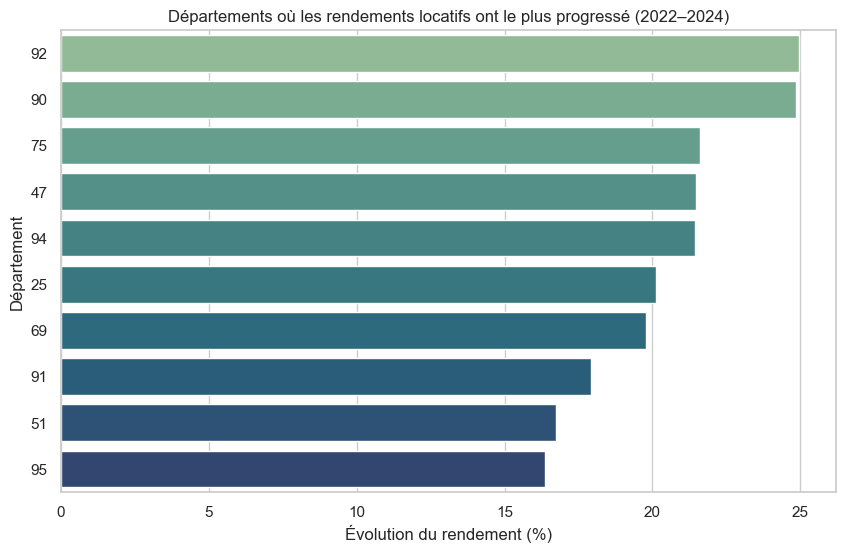

In [285]:
#Visualisation des départements avec la plus forte croissance des rendements locatifs (2022–2024)
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_rendement_growth,
    x="evolution_pct",
    y="departement",
    palette="crest")

plt.title("Départements où les rendements locatifs ont le plus progressé (2022–2024)")
plt.xlabel("Évolution du rendement (%)")
plt.ylabel("Département")
plt.show()

In [286]:
#Top 10 départements avec la plus forte baisse des rendements locatifs entre 2022 et 2024
rendement_pivot.sort_values("evolution_pct").head(10)

annee,departement,2022,2023,2024,evolution_pct
48,48,5.227759,5.006586,5.122474,-2.013958
55,55,6.598483,6.362326,6.608339,0.149361
43,43,5.107704,4.967356,5.185483,1.522769
9,10,6.137889,5.779471,6.252673,1.870095
40,40,4.503998,4.279582,4.631176,2.823681
60,61,5.563872,5.749438,5.722332,2.848010
67,70,6.682806,6.841979,6.881031,2.966201
7,08,6.215189,6.052495,6.403983,3.037622
4,05,4.375637,4.394389,4.538930,3.731871
11,12,5.401488,5.443899,5.611630,3.890433


L'analyse du marché immobilier entre 2022 et 2024 met en évidencce plusieurs tendances : 
- certains marchés immobiliers très chers ont connu une correction des prix
- les loyers augmentent dans la majorité des territoires
- les rendements locatifs progressent globalement

<div style="background-color: #0078B8; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">5 - Impact de la dynamique démographique</h2>
</div>

La croissance démographique est souvent un facteur important de la demande immobilière. Cette partie analyse les liens entre :
- croissance de population → identifier les territoires en expension démographique
- évolution des prix → relation croissance et prix immobiliers 
- rendement locatif → comprendre si les territoires en croissance offrent de meilleures opportunités d'investissement

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">5.1 - Croissance démographique par commune </h3>
</div>

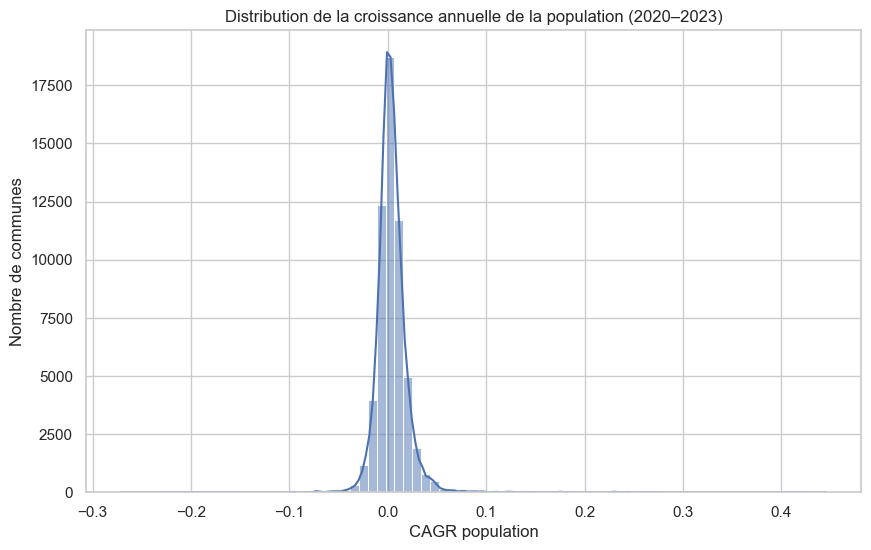

In [287]:
#Distribution de la croissance annuelle de la population (2020–2023)
plt.figure(figsize=(10,6))

sns.histplot(
    df_immo["cagr_pop_2020_2023"],
    bins=80,
    kde=True)

plt.title("Distribution de la croissance annuelle de la population (2020–2023)")
plt.xlabel("CAGR population")
plt.ylabel("Nombre de communes")
plt.show()

La distribution de la croissance annuelle de la population entre 2020 et 2023 montre que :
- la majorité des communes présentent une croissance proche de zéro
- certaines communes connaissent une croissance démographique positive plus marquée
- quelques territoires enregistrent une baisse de population

Cette distribution indique que la croissance démographique est globalement modérée en France, avec des variations importantes selon les territoires.

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">5.2 - Lien entre démographie et marché immobilier </h3>
</div>

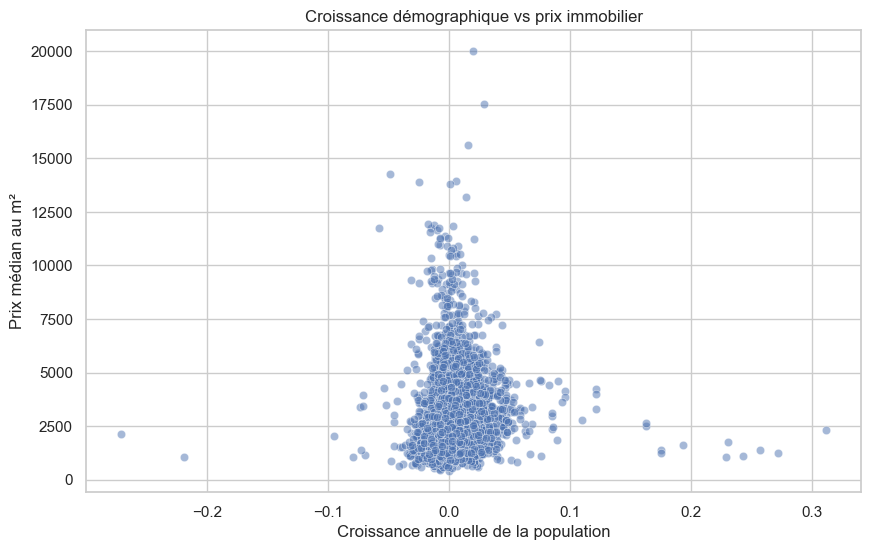

In [288]:
#Croissance démographique vs prix immobilier
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_immo.sample(6000),
    x="cagr_pop_2020_2023",
    y="prix_m2_median",
    alpha=0.5)

plt.title("Croissance démographique vs prix immobilier")
plt.xlabel("Croissance annuelle de la population")
plt.ylabel("Prix médian au m²")
plt.show()

Le graphique comparant la croissance démographique et les prix immobiliers montre que :
- les communes avec forte croissance démographique présentent généralement des prix immobiliers plus élevés
- les territoires en stagnation démographique ont souvent des prix immobiliers plus faibles

Cependant, la relation reste modérée.

La croissance de la population peut soutenir la demande immobilière, mais les prix dépendent également d'autres facteurs :
- attractivité économique
- localisation géographique
- accessibilité aux grandes métropoles.

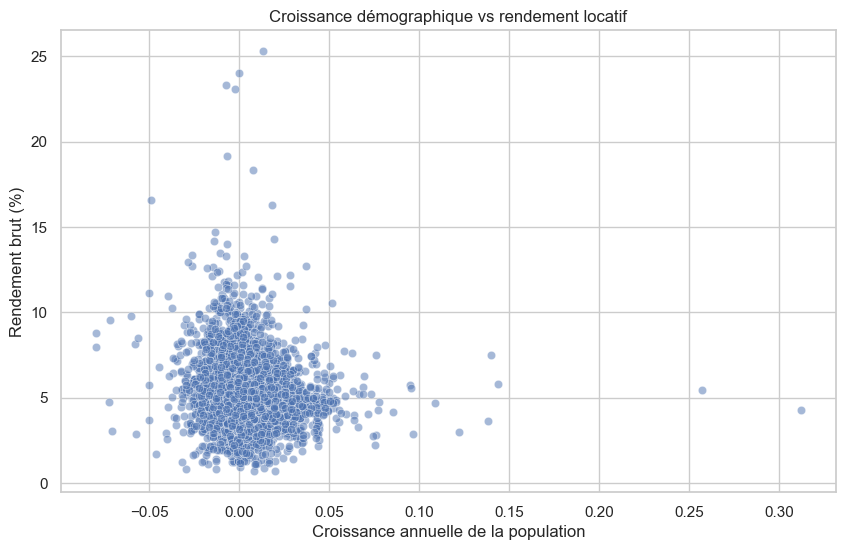

In [289]:
#Croissance démographique vs rendement locatif
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_immo.sample(6000),
    x="cagr_pop_2020_2023",
    y="rendement_brut_pct",
    alpha=0.5)

plt.title("Croissance démographique vs rendement locatif")
plt.xlabel("Croissance annuelle de la population")
plt.ylabel("Rendement brut (%)")
plt.show()

L’analyse du lien entre croissance démographique et rendement locatif montre que :
- les rendements locatifs restent relativement similaires entre les différentes catégories de croissance
- les territoires en forte croissance démographique ne présentent pas systématiquement des rendements plus élevés

Dans les zones attractives démographiquement :
- les prix immobiliers ont tendance à augmenter
- ce qui peut comprimer les rendements locatifs

À l’inverse, certaines zones à croissance démographique plus faible peuvent offrir des rendements plus élevés.

In [290]:
#Classification des communes en 4 catégories de croissance démographique
df_immo["classe_croissance_pop"] = pd.qcut(
    df_immo["cagr_pop_2020_2023"],
    q=4,
    labels=[
        "croissance faible",
        "croissance modérée",
        "croissance forte",
        "croissance très forte"])

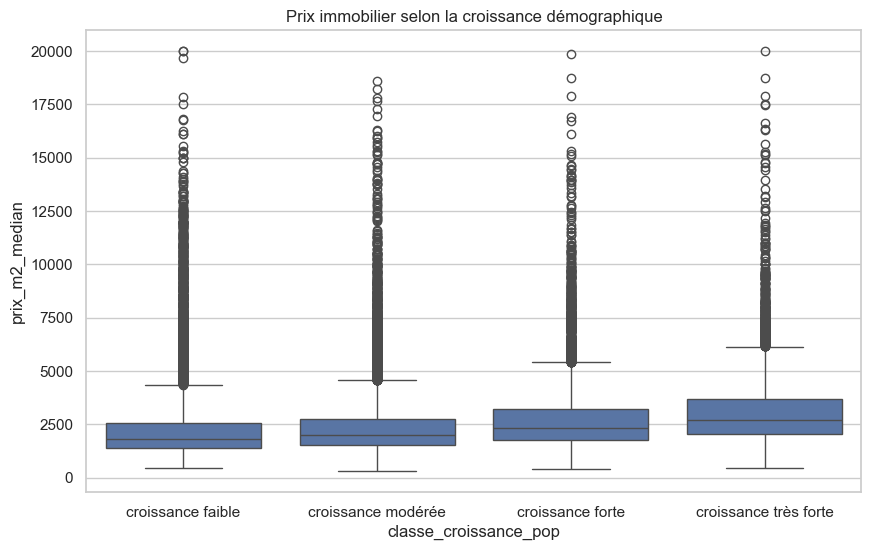

In [291]:
#Prix immobilier selon la croissance démographique
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_immo,
    x="classe_croissance_pop",
    y="prix_m2_median")

plt.title("Prix immobilier selon la croissance démographique")
plt.show()

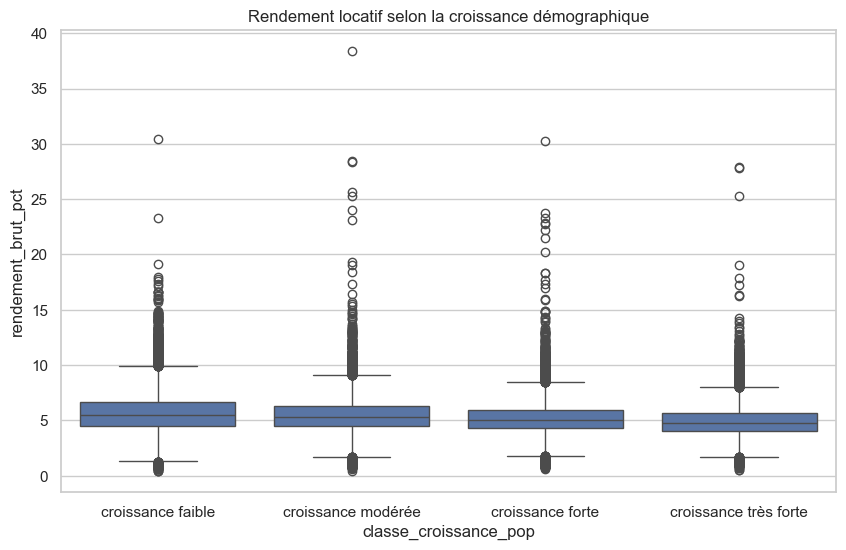

In [292]:
#Rendement locatif selon la croissance démographique
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_immo,
    x="classe_croissance_pop",
    y="rendement_brut_pct")

plt.title("Rendement locatif selon la croissance démographique")
plt.show()

L’analyse par catégories de croissance démographique met en évidence plusieurs tendances.

Prix immobiliers → Les communes présentant une croissance démographique forte ou très forte ont en moyenne des prix immobiliers plus élevés. Cela suggère que la croissance démographique peut contribuer à soutenir la demande immobilière.

Rendement locatif → Les rendements locatifs apparaissent relativement similaires entre les différentes catégories de croissance démographique. Cela confirme que :
- les zones dynamiques démographiquement sont souvent plus chères
- ce qui limite parfois la rentabilité locative.

<div style="background-color: #0078B8; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">6 - Construction d'un score d'investissement locatif</h2>
</div>

Afin d'identifier les communes les plus attractives pour l'investissement locatif, nous construisons un score d'investissement. Le score combine plusieurs dimensions :
- rendement locatif
- croissance démographique
- dynamique du marché
- lquidité du marché immobilier

L’objectif est de construire deux scores permettant d’identifier les communes présentant un potentiel d’investissement :
- score locatif : orienté rentabilité
- score patrimonial : orienté valorisation à long terme

Ces scores combinent plusieurs indicateurs issus des analyses précédentes.

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">6.1 - Méthodologie du score</h3>
</div>

#### Score investissement locatif

Variables utilisées :
- rendement_brut_pct → indicateur principal de rentabilité
- loyer_m2 → niveau de demande locative
- nb_ventes → liquidité du marché

#### Score investissement patrimonial

Variables utilisées :

- croissance_pop_2020_2023 → attractivité territoriale
- évolution des prix immobiliers entre 2022 et 2024 → dynamique du marché
- nb_ventes → dynamisme du marché

In [293]:
#Les variables doivent être normalisées afin d’être comparables.
#On utilise un MinMax scaling pour obtenir des valeurs entre 0 et 1.

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [294]:
#Score locatif : rendement brut, loyer au m² et nombre de ventes
features_locatif = [
    "rendement_brut_pct",
    "loyer_m2",
    "nb_ventes"]

df_immo[[f"{c}_norm" for c in features_locatif]] = scaler.fit_transform(df_immo[features_locatif])

In [295]:
#Calcul de la croissance des prix immobiliers entre 2022 et 2024 pour chaque commune
price_trend = (df_immo.groupby(["Code_INSEE","annee"])["prix_m2_median"].median().unstack())

price_trend["price_growth"] = ((price_trend[2024] - price_trend[2022]) /price_trend[2022])

price_trend = price_trend.reset_index()

In [296]:
#Intégration de la croissance des prix immobiliers dans le DataFrame principal
df_immo = df_immo.merge(
    price_trend[["Code_INSEE","price_growth"]],
    on="Code_INSEE",
    how="left")

In [297]:
#Score patrimonial : croissance démographique, prix au m² et nombre de ventes
features_patrimonial = [
    "price_growth",
    "cagr_pop_2020_2023",
    "nb_ventes"]

df_immo[[f"{c}_norm" for c in features_patrimonial]] = scaler.fit_transform(df_immo[features_patrimonial])

Afin de limiter l'impact des valeurs extrêmes observées dans l'évolution des prix immobiliers, les valeurs de coirssance vont être cappées entre -100 % et + 100 %

In [298]:
#Pondération des variables pour calculer un score patrimonial global
df_immo["price_growth"] = df_immo["price_growth"].clip(-1, 1)

La construction des scores d’investissement repose sur une combinaison de plusieurs indicateurs du marché immobilier. Chaque indicateur reçoit une pondération spécifique, reflétant son importance relative dans une stratégie d’investissement.L’objectif n’est pas de construire un modèle prédictif, mais de créer un indicateur synthétique d’aide à la décision.

#### Pondération du score d’investissement locatif

Le score locatif vise à identifier les communes offrant le meilleur potentiel de rentabilité locative.

Les variables retenues sont :
- rendement_brut_pct → 50 % → Le rendement locatif reçoit le poids le plus élevé (50 %) car il constitue le principal critère pour un investisseur locatif.
- loyer_m2 → 30 % → Le niveau de loyer (30 %) permet d’identifier les marchés où la demande locative est forte.
- nb_ventes → 20 % → Le nombre de ventes (20 %) mesure la liquidité du marché immobilier. Un marché actif facilite l’achat et la revente du bien.

#### Pondération du score patrimonial

Le score patrimonial vise à identifier les territoires présentant un potentiel de valorisation immobilière à long terme.

Les variables retenues sont :
- price_growth → 50 % → indicateur principal de valorisation immobilière (50 %).
- cagr_pop_2020_2023 → 30 % → La croissance démographique (30 %) est un indicateur clé de l’attractivité d’un territoire. Une population en croissance peut soutenir la demande immobilière sur le long terme.
- nb_ventes → 20 % → Le nombre de ventes (20 %) permet de mesurer le dynamisme du marché immobilier.

#### Limites de la méthode

Cette approche repose sur une pondération basée sur une logique économique du marché immobilier. Les pondérations pourraient être ajustées selon : 
- la stratégie d'investissement
- l'horizon d'investissement 
- le profil de risuqe de l'investisseur

Ces pondérations pourraient également être optimisés à partir de méthodes statisitques ou d'analyses historique.

In [299]:
#Pondération des variables pour calculer un score locatif global
df_immo["score_locatif"] = (
      df_immo["rendement_brut_pct_norm"] * 0.5
    + df_immo["loyer_m2_norm"] * 0.3
    + df_immo["nb_ventes_norm"] * 0.2)

In [300]:
#Pondération des variables pour calculer un score patrimonial global
df_immo["score_patrimonial"] = (
      df_immo["price_growth"] * 0.5
    + df_immo["cagr_pop_2020_2023"] * 0.3
    + df_immo["nb_ventes_norm"] * 0.2)

In [301]:
#Conversion des scores en pourcentage pour une meilleure lisibilité
df_immo["score_locatif"] = df_immo["score_locatif"] * 100
df_immo["score_patrimonial"] = df_immo["score_patrimonial"] * 100

<div style="background-color: #00B6DA; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">6.2 - Identification des communes les plus attractives </h3>
</div>

In [302]:
#Top 20 communes avec le meilleur score locatif
top_locatif = (df_immo.sort_values("score_locatif", ascending=False).head(20))

top_locatif[[
    "Code_INSEE",
    "score_locatif",
    "rendement_brut_pct",
    "loyer_m2"]]

,Code_INSEE,score_locatif,rendement_brut_pct,loyer_m2
46704,77255,61.787173,38.393914,18.458613
2740,06066,49.733002,30.304219,16.835677
38876,64343,45.321252,30.455723,11.535105
34904,59569,42.779233,27.931833,12.343613
34909,59569,42.734182,27.855777,12.462633
56571,95219,42.088847,23.766766,16.552379
56570,95219,41.613207,21.529177,20.241911
32747,56166,40.010091,25.617739,12.650117
21001,35130,39.991556,28.497064,8.361815
34906,59569,39.675040,25.297506,12.728305


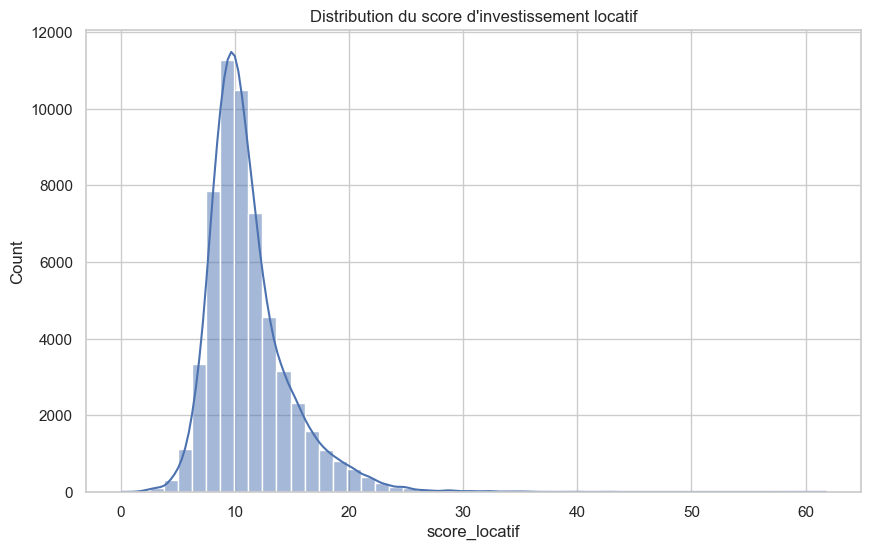

In [303]:
#Distribution du score d'investissement locatif
plt.figure(figsize=(10,6))

sns.histplot(df_immo["score_locatif"], bins=50, kde=True)
plt.title("Distribution du score d'investissement locatif")
plt.show()

La distribution du score locatif montre une forte concentration des communes autour d’un score compris entre 8 et 15 :
- la majorité des communes présentent un score relativement modéré
- seules quelques communes présentent des scores très élevés (supérieurs à 30)
- ces valeurs élevées correspondent souvent à des marchés avec rendement locatif élevé

Cette distribution indique que les opportunités locatives les plus attractives sont relativement rares et concentrées dans un nombre limité de territoires.

Afin d’identifier les types de biens les plus attractifs pour un investissement locatif, nous analysons la distribution du score locatif selon le segment de bien.
- Maison
- Appartements 1–2 pièces
- Appartements 3 pièces et plus

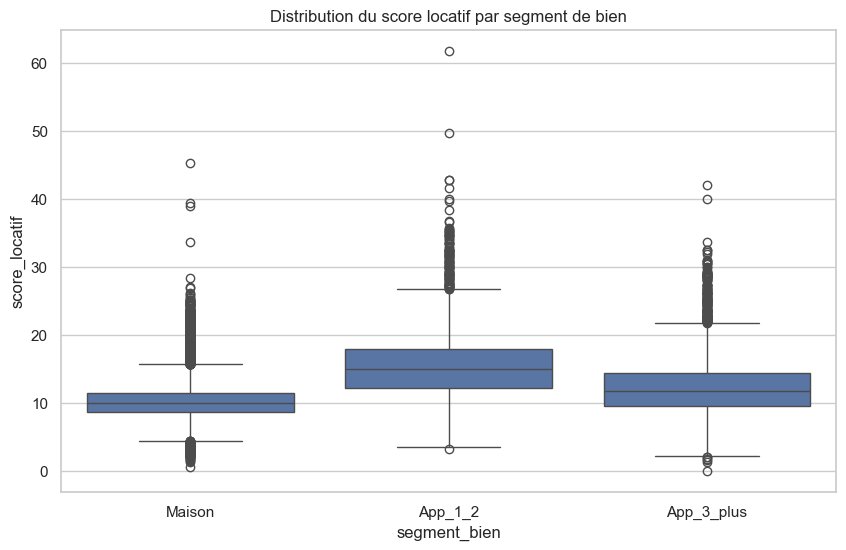

In [304]:
#Distribution du score locatif par segment de bien
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_immo,
    x="segment_bien",
    y="score_locatif")

plt.title("Distribution du score locatif par segment de bien")
plt.show()

#### Appartements 1–2 pièces
Les appartements de petite surface présentent les scores locatifs les plus élevés en moyenne. Cela s’explique par :
- des loyers au m² généralement plus élevés
- un prix d’acquisition souvent plus accessible
- une demande locative forte (étudiants, jeunes actifs, mobilité professionnelle).

Ces caractéristiques conduisent généralement à des rendements locatifs supérieurs.

#### Appartements 3 pièces et plus
Les appartements familiaux présentent un score locatif intermédiaire. Bien que les loyers soient élevés en valeur absolue, le loyer au m² est souvent inférieur à celui des petites surfaces, ce qui peut réduire le rendement locatif.Ces biens peuvent cependant offrir :
- une plus grande stabilité locative
- des durées d’occupation plus longues.

#### Maisons
Les maisons présentent en moyenne les scores locatifs les plus faibles. Cela peut s’expliquer par :
- un prix d’acquisition plus élevé
- un loyer au m² généralement plus faible
- un marché locatif parfois plus limité selon les territoires.

Les maisons sont souvent davantage recherchées dans une logique patrimoniale ou résidentielle plutôt que dans une stratégie de rendement locatif.

In [305]:
#Top 20 communes avec le meilleur score patrimonial
top_patrimonial = (df_immo.sort_values("score_patrimonial", ascending=False).head(20))

top_patrimonial[[
    "Code_INSEE",
    "score_patrimonial",
    "price_growth",
    "cagr_pop_2020_2023"]]

,Code_INSEE,score_patrimonial,price_growth,cagr_pop_2020_2023
52771,86247,57.084316,1.000000,0.234904
52770,86247,57.080595,1.000000,0.234904
52772,86247,57.050828,1.000000,0.234904
42153,71566,56.148783,0.984222,0.229147
42154,71566,56.096690,0.984222,0.229147
42158,71566,56.092969,0.984222,0.229147
42157,71566,56.089248,0.984222,0.229147
42156,71566,56.089248,0.984222,0.229147
42155,71566,56.085527,0.984222,0.229147
4896,11310,51.944231,1.000000,0.064436


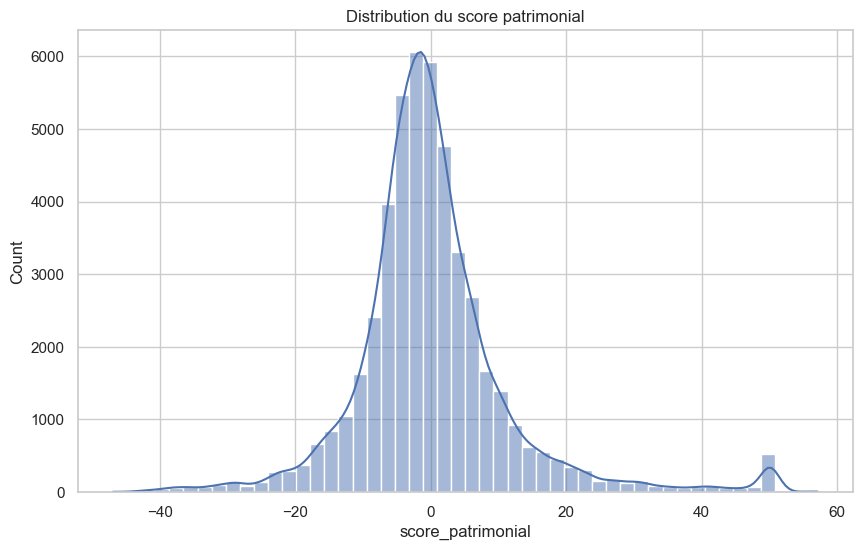

In [306]:
#Distribution du score patrimonial
plt.figure(figsize=(10,6))

sns.histplot(df_immo["score_patrimonial"], bins=50, kde=True)
plt.title("Distribution du score patrimonial")
plt.show()

La distribution du score patrimonial montre une répartition plus équilibrée des communes. La majorité des communes se situent autour d’un score proche de 0, ce qui reflète :
- une croissance immobilière modérée
- une dynamique démographique relativement stable.

Les communes présentant les scores patrimoniaux les plus élevés combinent généralement :
- une croissance des prix immobiliers importante
- une dynamique démographique positive
- un marché immobilier relativement actif.

Ces territoires peuvent être considérés comme les marchés les plus attractifs pour une stratégie patrimoniale à long terme.

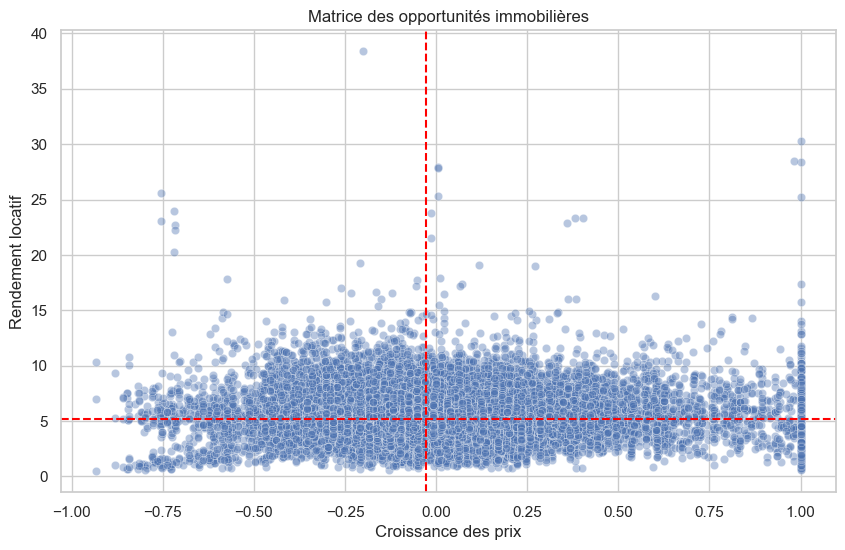

In [307]:
#Matrice des opportunités immobilières : croissance des prix vs rendement locatif
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_immo,
    x="price_growth",
    y="rendement_brut_pct",
    alpha=0.4)

plt.axvline(df_immo["price_growth"].median(), color="red", linestyle="--")
plt.axhline(df_immo["rendement_brut_pct"].median(), color="red", linestyle="--")
plt.title("Matrice des opportunités immobilières")
plt.xlabel("Croissance des prix")
plt.ylabel("Rendement locatif")
plt.show()

La matrice représentant la relation entre :
- la croissance des prix immobiliers
- le rendement locatif

permet d’identifier plusieurs profils de marchés immobiliers.

Les lignes pointillées représentent les valeurs médianes du marché :
- croissance des prix médiane
- rendement locatif médian.

Cette représentation permet de distinguer quatre grandes catégories de marchés :

Opportunités complètes le communes combinant :
- forte croissance des prix
- rendement locatif supérieur à la médiane.

Ces territoires représentent les opportunités les plus intéressantes pour les investisseurs.

<div style="background-color: #0078B8; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">7 - Préparation des données pour le dashboard Power BI</h2>
</div>

<div style="background-color: #0078B8; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">8 - Conclusion et principaux enseignements</h2>
</div>